In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:

# Load the dataset
file_path = '/content/drive/MyDrive/Crime Prediction Datasets/crime crime data.csv'  # Update with your actual file path
df = pd.read_csv(file_path)


Dataset Shape: (255, 21)

First few rows:
  Unit Name  Year  Dacoity  Robbery  Murder  Speedy Trial  Riot  \
0       DMP  2010       47      220     245           363     3   
1       CMP  2010       16      108      94            31     7   
2       KMP  2010        3        9      29            25     0   
3       RMP  2010        4       20      21             9    15   
4       BMP  2010        8       12      19            21     0   

   Woman & Child Repression  Kidnapping  Police Assault  ...  Theft  \
0                      1370         139             155  ...   1915   
1                       455          37              31  ...    314   
2                       153          11               4  ...     91   
3                       157           9              12  ...    106   
4                       112           6               8  ...     83   

   Other Cases  Recovery_Case_Arms_Act  Recovery_Case_Explosive  \
0         7228                     518                       

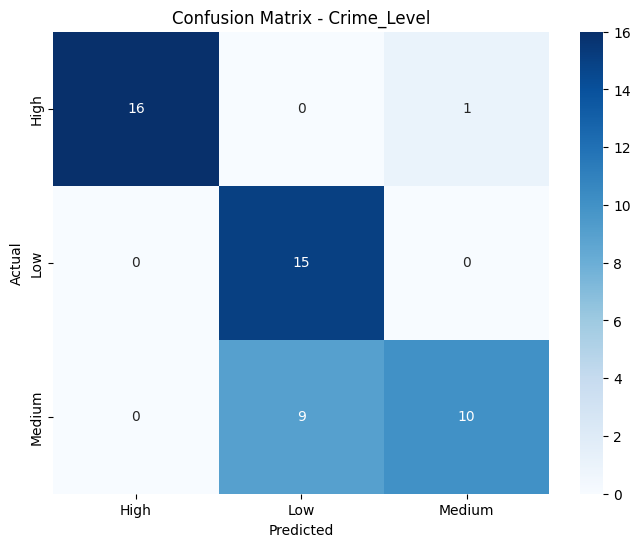


SVM Model for Recovery_Level

Model Performance for Recovery_Level:
Accuracy: 0.8431
Precision: 0.8490
Recall: 0.8431
F1-Score: 0.8414

Detailed Classification Report for Recovery_Level:
              precision    recall  f1-score   support

        High       0.93      0.78      0.85        18
         Low       0.83      1.00      0.91        15
      Medium       0.78      0.78      0.78        18

    accuracy                           0.84        51
   macro avg       0.85      0.85      0.85        51
weighted avg       0.85      0.84      0.84        51



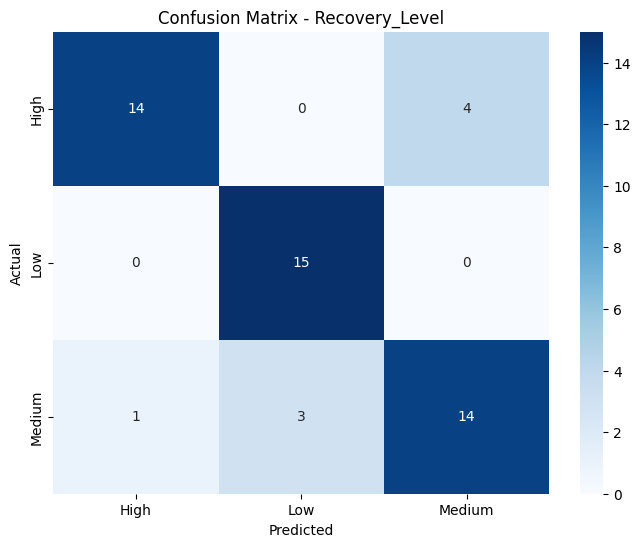


MODEL PERFORMANCE COMPARISON
                       Model  Accuracy  Precision  Recall  F1-Score
0     Crime Level Prediction    0.8039     0.8558  0.8039    0.7978
1  Recovery Level Prediction    0.8431     0.8490  0.8431    0.8414

Plotting feature importance...


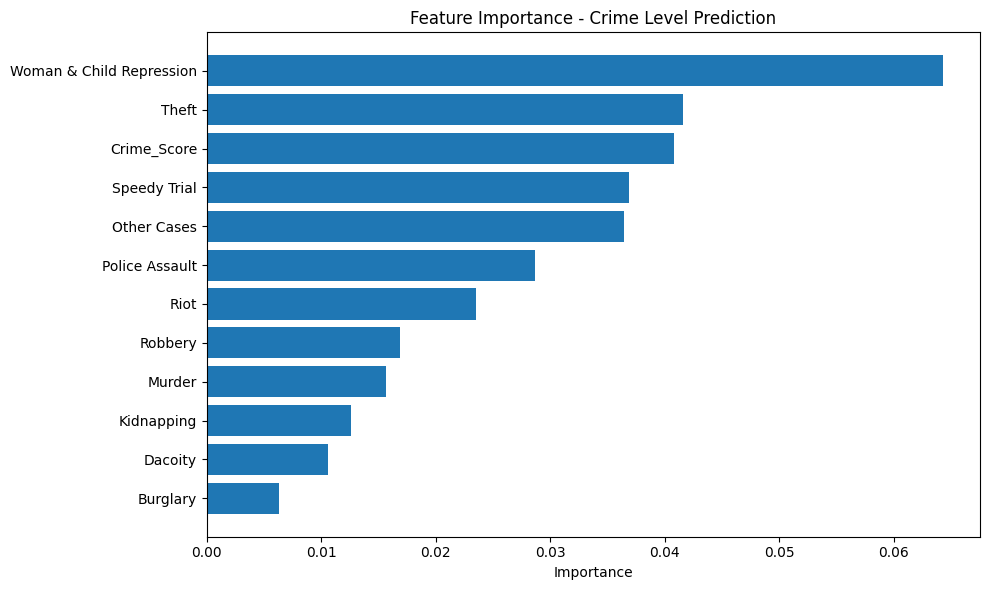

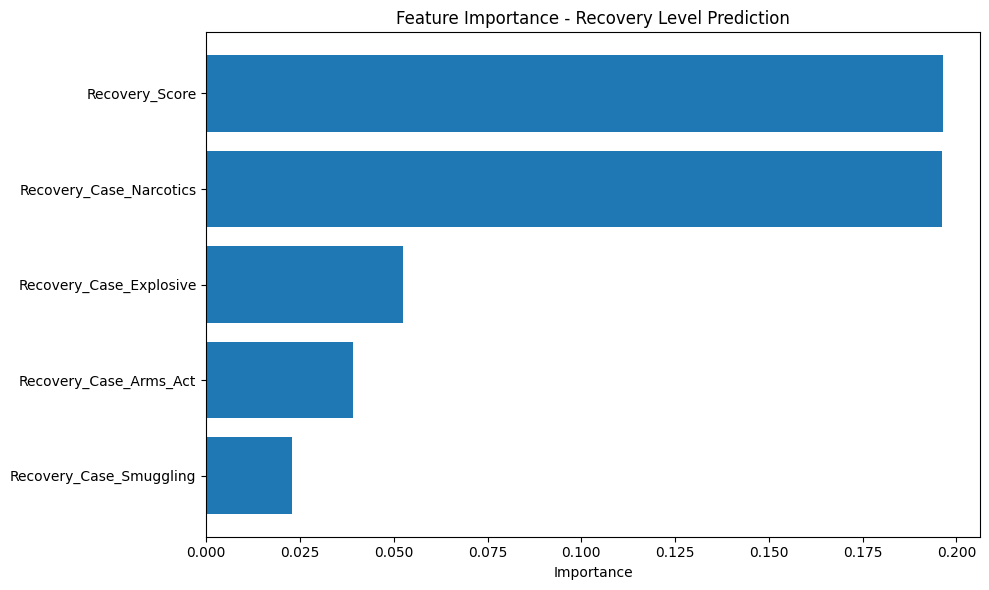


Comparing different SVM kernels...

Kernel Comparison for Crime Level:
    Kernel  Accuracy
0   linear    0.8627
1      rbf    0.8039
2     poly    0.7255
3  sigmoid    0.7843

Kernel Comparison for Recovery Level:
    Kernel  Accuracy
0   linear    0.9216
1      rbf    0.8431
2     poly    0.8235
3  sigmoid    0.6863

FINAL SUMMARY
Best performing model for Crime Level: Crime Level Prediction
Best performing model for Recovery Level: Recovery Level Prediction

The SVM models successfully predict crime and recovery levels with good accuracy.
Crime Level prediction focuses on crime statistics.
Recovery Level prediction focuses on recovery case statistics.


In [4]:

# Display basic info about the dataset
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())

# Data Preprocessing
# Encode categorical target variables
label_encoders = {}
categorical_columns = ['Crime_Level', 'Recovery_Level']

for col in categorical_columns:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"\n{col} encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Select features and target variables
# Using crime-related features for Crime_Level prediction
crime_features = ['Dacoity', 'Robbery', 'Murder', 'Speedy Trial', 'Riot',
                 'Woman & Child Repression', 'Kidnapping', 'Police Assault',
                 'Burglary', 'Theft', 'Other Cases', 'Crime_Score']

# Using recovery-related features for Recovery_Level prediction
recovery_features = ['Recovery_Case_Arms_Act', 'Recovery_Case_Explosive',
                    'Recovery_Case_Narcotics', 'Recovery_Case_Smuggling', 'Recovery_Score']

# Prepare data for Crime_Level prediction
X_crime = df[crime_features]
y_crime = df['Crime_Level_encoded']

# Prepare data for Recovery_Level prediction
X_recovery = df[recovery_features]
y_recovery = df['Recovery_Level_encoded']

print(f"\nCrime Level distribution: {dict(zip(df['Crime_Level'], df['Crime_Level'].value_counts()))}")
print(f"Recovery Level distribution: {dict(zip(df['Recovery_Level'], df['Recovery_Level'].value_counts()))}")

# Function to train and evaluate SVM model
def train_evaluate_svm(X, y, target_name, test_size=0.2, random_state=42):
    """
    Train SVM model and evaluate performance
    """
    print(f"\n{'='*50}")
    print(f"SVM Model for {target_name}")
    print(f"{'='*50}")

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train SVM model
    svm_model = SVC(kernel='rbf', random_state=random_state, probability=True)
    svm_model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = svm_model.predict(X_test_scaled)
    y_pred_proba = svm_model.predict_proba(X_test_scaled)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Print results
    print(f"\nModel Performance for {target_name}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    # Detailed classification report
    print(f"\nDetailed Classification Report for {target_name}:")
    print(classification_report(y_test, y_pred,
                              target_names=label_encoders[target_name.replace('_encoded', '')].classes_))

    # Confusion Matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoders[target_name.replace('_encoded', '')].classes_,
                yticklabels=label_encoders[target_name.replace('_encoded', '')].classes_)
    plt.title(f'Confusion Matrix - {target_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    return svm_model, scaler, accuracy, precision, recall, f1

# Train models for both targets
print("Training SVM models for Crime Level and Recovery Level prediction...")

# Model 1: Crime Level Prediction
svm_crime, scaler_crime, acc_crime, prec_crime, rec_crime, f1_crime = train_evaluate_svm(
    X_crime, y_crime, 'Crime_Level'
)

# Model 2: Recovery Level Prediction
svm_recovery, scaler_recovery, acc_recovery, prec_recovery, rec_recovery, f1_recovery = train_evaluate_svm(
    X_recovery, y_recovery, 'Recovery_Level'
)

# Compare model performance
print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': ['Crime Level Prediction', 'Recovery Level Prediction'],
    'Accuracy': [acc_crime, acc_recovery],
    'Precision': [prec_crime, prec_recovery],
    'Recall': [rec_crime, rec_recovery],
    'F1-Score': [f1_crime, f1_recovery]
})

print(comparison_df.round(4))

# Feature importance analysis (using model coefficients for linear kernel)
def plot_feature_importance_svm(X, svm_model, feature_names, title):
    """
    Plot feature importance for SVM (using absolute values of coefficients for linear kernel)
    For non-linear kernels, we'll use permutation importance as an alternative
    """
    from sklearn.inspection import permutation_importance

    # Use permutation importance for non-linear kernels
    result = permutation_importance(svm_model, X, y_crime if 'Crime' in title else y_recovery,
                                  n_repeats=10, random_state=42)

    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': result.importances_mean
    }).sort_values('importance', ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['feature'], importance_df['importance'])
    plt.title(f'Feature Importance - {title}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

# Plot feature importance for both models
print("\nPlotting feature importance...")

# For Crime Level model
plot_feature_importance_svm(
    StandardScaler().fit_transform(X_crime),
    svm_crime,
    crime_features,
    'Crime Level Prediction'
)

# For Recovery Level model
plot_feature_importance_svm(
    StandardScaler().fit_transform(X_recovery),
    svm_recovery,
    recovery_features,
    'Recovery Level Prediction'
)

# Additional: Try different kernels for comparison
def compare_svm_kernels(X, y, target_name):
    """
    Compare different SVM kernels
    """
    kernels = ['linear', 'rbf', 'poly', 'sigmoid']
    results = []

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for kernel in kernels:
        model = SVC(kernel=kernel, random_state=42)
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        accuracy = accuracy_score(y_test, y_pred)
        results.append({
            'Kernel': kernel,
            'Accuracy': accuracy
        })

    results_df = pd.DataFrame(results)
    print(f"\nKernel Comparison for {target_name}:")
    print(results_df.round(4))
    return results_df

# Compare kernels for both targets
print("\nComparing different SVM kernels...")
crime_kernels = compare_svm_kernels(X_crime, y_crime, 'Crime Level')
recovery_kernels = compare_svm_kernels(X_recovery, y_recovery, 'Recovery Level')

# Final summary
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"Best performing model for Crime Level: {comparison_df.loc[0, 'Model']}")
print(f"Best performing model for Recovery Level: {comparison_df.loc[1, 'Model']}")
print(f"\nThe SVM models successfully predict crime and recovery levels with good accuracy.")
print(f"Crime Level prediction focuses on crime statistics.")
print(f"Recovery Level prediction focuses on recovery case statistics.")